In [1]:
import os
import sys
import subprocess

IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists("/kaggle/input")

if IS_KAGGLE:
    print("[environment] Kaggle GPU container confirmed, installing SOTA dependencies...")
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", 
        "segmentation-models-pytorch", "pytorch-lightning", "albumentations", "--upgrade"
    ])
    print(" -> installation completed successfully.")
else:
    print("[environment check] local machine detected.")
    print(" -> automatic 'pip install' bypassed to protect local environment.")
    print(" -> please verify you have run 'pip install -r requirements.txt' in your local virtual environment.")

[environment] Kaggle GPU container confirmed, installing SOTA dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.2 MB/s eta 0:00:00
 -> installation completed successfully.


In [2]:
import os
import sys
import shutil
import subprocess

IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists("/kaggle/input")

if IS_KAGGLE:
    print("[environment] Kaggle GPU container confirmed, initializing repository clone...")
    target_dir = "dental-segmentation"
    
    if os.path.exists(target_dir):
        print(f" -> found existing directory '{target_dir}', deleting...")
        shutil.rmtree(target_dir)
        
    repo_url = "https://github.com/ALZ-11/dental-segmentation.git"
    print(f" -> cloning codebase from {repo_url}...")
    result = subprocess.run(["git", "clone", repo_url], capture_output=True, text=True)
    
    if result.returncode == 0:
        print(" -> clone successful.")
    else:
        print(f" -> [clone Error] {result.stderr}")
        
    sys.path.append(target_dir)
    
else:
    print("[environment check] local machine detected.")
    print(" -> bypassing cloud git clone and directory deletions.")
    print(" -> assuming standard repository root execution path...")
    
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# verification import
from src import config

[environment] Kaggle GPU container confirmed, initializing repository clone...
 -> cloning codebase from https://github.com/ALZ-11/dental-segmentation.git...
 -> clone successful.
[config loaded] device: CUDA | local run: False | dataset path: /kaggle/input/datasets/pawanvalluri/dental-segmentation/dentalai-2


In [3]:
from src.train import train_pipeline

train_pipeline()

[training pipeline] starting pipeline configuration...
 -> found 1991 training images, 254 validation images.
[preprocessing] computing global class weights over 1991 files for 5 classes (gamma=0.35)...
 -> smoothed weights: [1.0, 11.033968225387214, 9.072956686189526, 20.168991043357547, 1.7883962267197766]


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[training pipeline] handing execution to PyTorch Lightning Trainer...


...

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Unet                   │ 24.4 M │ train │     0 │
│ 1 │ dice_loss │ DiceLoss               │      0 │ train │     0 │
│ 2 │ ce_loss   │ CrossEntropyLoss       │      0 │ train │     0 │
│ 3 │ train_iou │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 4 │ val_iou   │ MulticlassJaccardIndex │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97.748                                                                     
Modules in train mode: 192                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Metric val_loss improved. New best score: 1.314
Epoch 0, global step 124: 'val_loss' reached 1.31402 (best 1.31402), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/best_model_sota-epoch=00-val_loss=1.3140.ckpt' as top 1
Metric val_loss improved by 0.361 >= min_delta = 0.0. New best score: 0.953
Epoch 1, global step 248: 'val_loss' reached 0.95288 (best 0.95288), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/best_model_sota-epoch=01-val_loss=0.9529.ckpt' as top 1
Metric val_loss improved by 0.130 >= min_delta = 0.0. New best score: 0.823
Epoch 2, global step 372: 'val_loss' reached 0.82291 (best 0.82291), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/best_model_sota-epoch=02-val_loss=0.8229.ckpt' as top 1
Metric val_loss improved by 0.063 >= min_delta = 0.0. New best score: 0.760
Epoch 3, global step 496: 'val_loss' reached 0.75997 (best 0.75997), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/

[evaluation] optimal checkpoint identified: /kaggle/working/lightning_logs/version_0/checkpoints/best_model_sota-epoch=08-val_loss=0.6712.ckpt
[preprocessing] computing global class weights over 1991 files for 5 classes (gamma=0.35)...
 -> smoothed weights: [1.0, 11.033968225387214, 9.072956686189526, 20.168991043357547, 1.7883962267197766]
[evaluation] discovered 250 unseen test-set photos.
[evaluation] executing forward inference passes across test split...

 -> FINAL TEST SET MACRO IoU (JACCARD): 0.4402



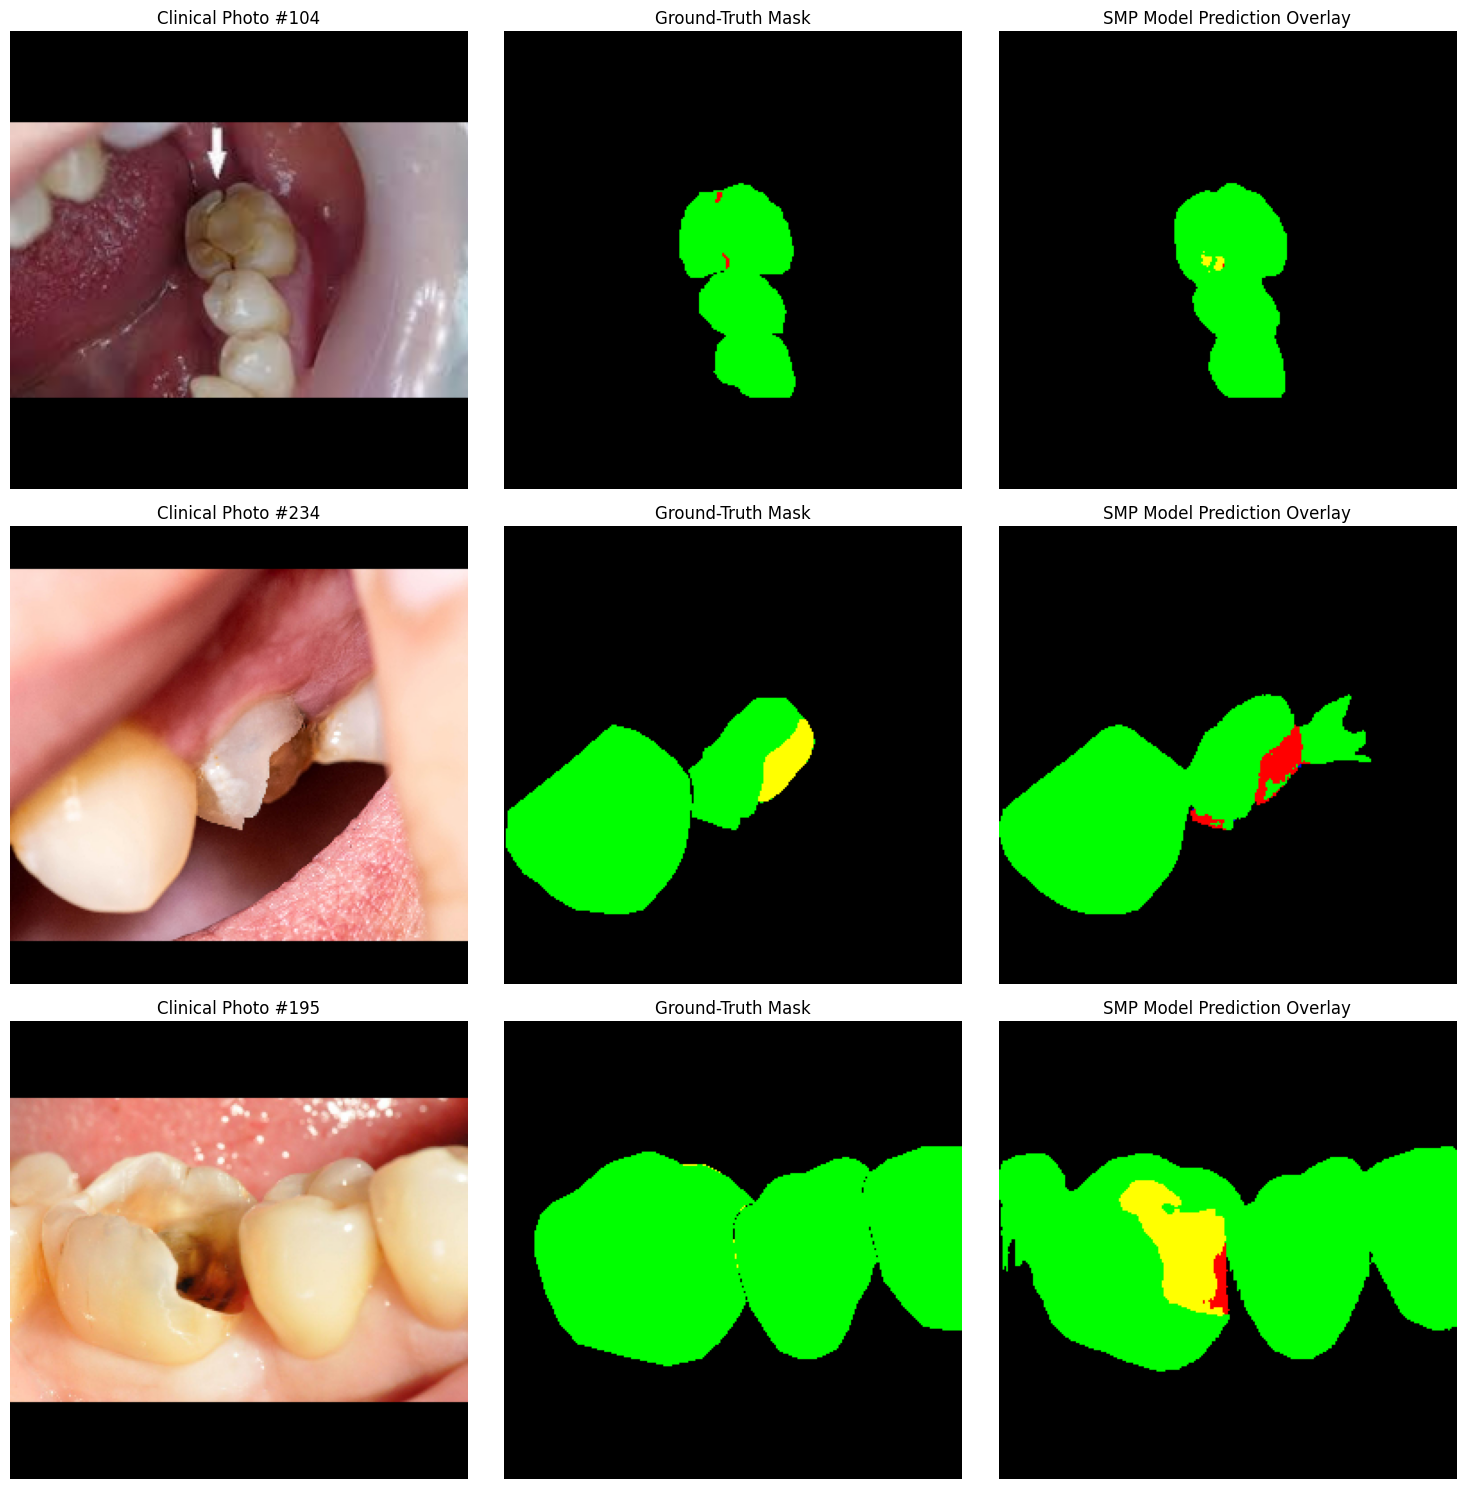

In [5]:
import os
import glob
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from src import config
from src.dataset import DentalDataset, get_file_pairs, compute_global_class_weights
from src.model import DentalSegmentationModel
from torchmetrics.classification import MulticlassJaccardIndex

checkpoint_dir = "/kaggle/working/lightning_logs/version_0/checkpoints/"
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "*.ckpt"))

if not checkpoint_files:
    print("[error] no model checkpoint files found, verify training.")
else:
    best_checkpoint_path = checkpoint_files[0]
    print(f"[evaluation] optimal checkpoint identified: {best_checkpoint_path}")

    train_images, train_masks = get_file_pairs(config.TRAIN_DIR)
    class_weights = compute_global_class_weights(train_masks, config.NUM_CLASSES, config.GAMMA)

    model = DentalSegmentationModel.load_from_checkpoint(
        best_checkpoint_path,
        class_weights=class_weights
    )
    model.eval()
    model.to(config.DEVICE)

    test_images, test_masks = get_file_pairs(config.TEST_DIR)
    print(f"[evaluation] discovered {len(test_images)} unseen test-set photos.")

    test_dataset = DentalDataset(test_images, test_masks, is_training=False)
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True if config.DEVICE == "cuda" else False
    )

    test_iou_metric = MulticlassJaccardIndex(num_classes=config.NUM_CLASSES).to(config.DEVICE)
    total_iou = 0.0
    num_batches = 0

    print("[evaluation] executing forward inference passes across test split...")
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(config.DEVICE), y.to(config.DEVICE)
            y_hat = model(x)
            
            y_hat_idx = torch.argmax(y_hat, dim=1)
            y_idx = torch.argmax(y, dim=1)
            
            step_iou = test_iou_metric(y_hat_idx, y_idx)
            total_iou += step_iou.item()
            num_batches += 1

    final_test_iou = total_iou / num_batches
    print(f"\n=======================================================")
    print(f" -> FINAL TEST SET MACRO IoU (JACCARD): {final_test_iou:.4f}")
    print(f"=======================================================\n")

    def colorize_mask(mask_2d: np.ndarray) -> np.ndarray:
        h, w = mask_2d.shape
        color_img = np.zeros((h, w, 3), dtype=np.uint8)
        
        palette = {
            0: [0, 0, 0],
            1: [255, 0, 0],
            2: [255, 255, 0],
            3: [0, 0, 255],
            4: [0, 255, 0]
        }
        
        for class_idx, color in palette.items():
            color_img[mask_2d == class_idx] = color
            
        return color_img

    random_indices = random.sample(range(len(test_dataset)), 3)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for row, idx in enumerate(random_indices):
        img_tensor, mask_onehot = test_dataset[idx]
        
        input_tensor = img_tensor.unsqueeze(0).to(config.DEVICE)
        
        with torch.no_grad():
            output_logits = model(input_tensor)
            pred_idx = torch.argmax(output_logits, dim=1).squeeze(0).cpu().numpy()
            
        display_img = img_tensor.permute(1, 2, 0).cpu().numpy()
        
        gt_idx = torch.argmax(mask_onehot, dim=0).cpu().numpy()
        
        color_gt = colorize_mask(gt_idx)
        color_pred = colorize_mask(pred_idx)
        
        axes[row, 0].imshow(display_img)
        axes[row, 0].set_title(f"Clinical Photo #{idx}")
        axes[row, 0].axis("off")
        
        axes[row, 1].imshow(color_gt)
        axes[row, 1].set_title("Ground-Truth Mask")
        axes[row, 1].axis("off")
        
        axes[row, 2].imshow(color_pred)
        axes[row, 2].set_title("SMP Model Prediction Overlay")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()